In [1]:
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

# Merging Be stars to Clusters

In [3]:
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord, search_around_sky, Angle
import astropy.units as u

def match_emitters_to_clusters(
    clusters: pd.DataFrame,
    stars: pd.DataFrame,
    *,
    cluster_ra_col: str = "ra",        # RA dos aglomerados (graus)
    cluster_dec_col: str = "dec",      # Dec dos aglomerados (graus)
    cluster_amaj_col: str = "amaj",    # semi-eixo maior (ex.: arcmin) — tratado como raio circular
    stars_ra_col: str = "ra",          # RA das estrelas (graus)
    stars_dec_col: str = "dec",        # Dec das estrelas (graus)
    amaj_unit: str = "arcmin",         # unidade do amaj (ex.: "arcmin", "arcsec", "deg")
    keep_cols_clusters: list | None = None,  # colunas extras do df de aglomerados para levar ao resultado
    keep_cols_stars: list | None = None,     # colunas extras do df de estrelas para levar ao resultado
) -> pd.DataFrame:
    """
    Associa estrelas Hα a aglomerados retornando apenas as que estão dentro do amaj de cada aglomerado.

    Parameters
    ----------
    clusters : pandas.DataFrame
        Tabela de aglomerados com colunas de posição e amaj.
    stars : pandas.DataFrame
        Tabela de estrelas emissoras com colunas de posição.
    cluster_ra_col : str, default "ra"
        Nome da coluna de RA dos aglomerados (em graus).
    cluster_dec_col : str, default "dec"
        Nome da coluna de Dec dos aglomerados (em graus).
    cluster_amaj_col : str, default "amaj"
        Nome da coluna do semi-eixo maior do aglomerado.
        **É interpretado como um raio circular** para a seleção.
    stars_ra_col : str, default "ra"
        Nome da coluna de RA das estrelas (em graus).
    stars_dec_col : str, default "dec"
        Nome da coluna de Dec das estrelas (em graus).
    amaj_unit : str, default "arcmin"
        Unidade de `amaj` (por exemplo: "arcmin", "arcsec" ou "deg").
    keep_cols_clusters : list[str] | None
        Colunas adicionais do DataFrame de aglomerados a incluir no resultado.
    keep_cols_stars : list[str] | None
        Colunas adicionais do DataFrame de estrelas a incluir no resultado.

    Returns
    -------
    pandas.DataFrame
        Uma tabela já mesclada contendo:
        - índices originais (`cluster_index`, `star_index`)
        - separação angular (`sep_arcsec`, `sep_arcmin`)
        - colunas dos aglomerados com prefixo `cluster_`
        - colunas das estrelas com prefixo `star_`

    Notes
    -----
    * `amaj` é tratado como **semi-eixo maior** em unidade dada por `amaj_unit` e
      usado como **raio circular equivalente** para o corte (i.e., sep <= amaj).
    * A rotina usa um raio máximo global (= max(amaj)) em `search_around_sky`
      e depois filtra par-a-par por `amaj` específico de cada aglomerado.
    * Linhas com posições/raios inválidos (NaN, não positivos) são ignoradas.
    """
    # Escolha das colunas para carregar/propagar
    if keep_cols_clusters is None:
        keep_cols_clusters = []
    if keep_cols_stars is None:
        keep_cols_stars = []

    # Filtrar entradas válidas nos aglomerados
    cl_req = [cluster_ra_col, cluster_dec_col, cluster_amaj_col] + keep_cols_clusters
    cl_df = clusters[cl_req].copy()
    cl_df = cl_df.replace([np.inf, -np.inf], np.nan).dropna(subset=[cluster_ra_col, cluster_dec_col, cluster_amaj_col])
    # descarta amaj <= 0
    cl_df = cl_df[cl_df[cluster_amaj_col] > 0].copy()

    # Filtrar entradas válidas nas estrelas
    st_req = [stars_ra_col, stars_dec_col] + keep_cols_stars
    st_df = stars[st_req].copy()
    st_df = st_df.replace([np.inf, -np.inf], np.nan).dropna(subset=[stars_ra_col, stars_dec_col])

    if cl_df.empty or st_df.empty:
        return pd.DataFrame(columns=[
            "cluster_index","star_index","sep_arcsec","sep_arcmin"
        ])

    # Coordenadas
    c_clusters = SkyCoord(ra=cl_df[cluster_ra_col].to_numpy() * u.deg,
                          dec=cl_df[cluster_dec_col].to_numpy() * u.deg)
    c_stars = SkyCoord(ra=st_df[stars_ra_col].to_numpy() * u.deg,
                       dec=st_df[stars_dec_col].to_numpy() * u.deg)

    # Raio máximo global para a busca
    unit = u.Unit(amaj_unit)
    max_amaj = np.nanmax(cl_df[cluster_amaj_col].to_numpy())
    seplimit = Angle(max_amaj, unit)

    # Busca inicial (eficiente)
    idx_cl, idx_st, sep2d, _ = search_around_sky(c_clusters, c_stars, seplimit=seplimit)

    if len(idx_cl) == 0:
        return pd.DataFrame(columns=[
            "cluster_index","star_index","sep_arcsec","sep_arcmin"
        ])

    # Limite específico por aglomerado (par-a-par)
    amaj_per_pair = Angle(cl_df.iloc[idx_cl][cluster_amaj_col].to_numpy(), unit)
    keep = sep2d <= amaj_per_pair

    if not np.any(keep):
        return pd.DataFrame(columns=[
            "cluster_index","star_index","sep_arcsec","sep_arcmin"
        ])

    # Construir resultado
    pairs = pd.DataFrame({
        "cluster_index": cl_df.index.values[idx_cl[keep]],
        "star_index": st_df.index.values[idx_st[keep]],
        "sep_arcsec": sep2d[keep].arcsec,
        "sep_arcmin": sep2d[keep].to(u.arcmin).value,
    })

    # Anexar metadados dos aglomerados e estrelas (com prefixos)
    cl_out = clusters.loc[pairs["cluster_index"]][[cluster_ra_col, cluster_dec_col, cluster_amaj_col] + keep_cols_clusters]
    cl_out = cl_out.add_prefix("cluster_").reset_index(drop=True)

    st_out = stars.loc[pairs["star_index"]][[stars_ra_col, stars_dec_col] + keep_cols_stars]
    st_out = st_out.add_prefix("star_").reset_index(drop=True)

    result = pd.concat([pairs.reset_index(drop=True), cl_out, st_out], axis=1)

    # Ordenar por separação (útil)
    result = result.sort_values("sep_arcmin", ascending=True).reset_index(drop=True)
    return result

In [21]:
bica = pd.read_csv('/home/marina/FullCatalogBica_08_20.csv')

In [13]:
be = pd.read_csv('/home/shared/splus_gaia/notebooks/magellanic_clouds/studying_diff_objs/selecting_stars_below_be.csv')

In [14]:
# clusters_df: colunas ["name","ra","dec","amaj"] (amaj em arcmin, por ex.)
# emitters_df: colunas ["source_id","ra","dec", ...]
out = match_emitters_to_clusters(
    bica,
    be,
    cluster_ra_col="ra_deg",
    cluster_dec_col="dec_deg",
    cluster_amaj_col="amaj",
    stars_ra_col="ra",
    stars_dec_col="dec",
    amaj_unit="arcmin",
    keep_cols_clusters=["Names"],         # traga o nome do aglomerado
    keep_cols_stars=["id","excess", "err_mag_psf_u", "err_mag_psf_j0378", "err_mag_psf_j0395",
       "err_mag_psf_j0410", "err_mag_psf_j0430", "err_mag_psf_g",
       "err_mag_psf_j0515", "err_mag_psf_r", "err_mag_psf_j0660",
       "err_mag_psf_i", "err_mag_psf_j0861", "err_mag_psf_z", "mag_psf_u",
       "mag_psf_j0378", "mag_psf_j0395", "mag_psf_j0410", "mag_psf_j0430",
       "mag_psf_g", "mag_psf_j0515", "mag_psf_r", "mag_psf_j0660", "mag_psf_i",
       "mag_psf_j0861", "mag_psf_z"]  # traga id/atributos da estrela
)

# "out" tem uma linha por estrela-associada, com "cluster_*" e "star_*"

In [15]:
gp1 = out.groupby('cluster_Names').size().reset_index(name='counts').sort_values(by='counts', ascending=False)

In [16]:
gp1

,cluster_Names,counts
1013,DEMS114,547
1018,DEMS124,471
597,"BS I,Bica-Schmitt I",415
1006,DEMS104,322
634,BS153,296
...,...,...
1244,H86-91,1
405,BMS15,1
1246,"H86-98,SOGLE44",1
1247,"H86-99,SOGLE190",1


In [ ]:
# dtypes = {
#     "id": "string",
#     "ra": "float32",
#     "dec": "float32",
#     "gaia_source_id": "string",
#     "parallax": "float32",
#     "gaia_ruwe": "float32",
#     "gaia_parallax_over_error": "float32",
#     "gaia_classprob_dsc_combmod_star": "float32",
#     "gaia_in_qso_candidates": "int8",
#     "gaia_in_galaxy_candidates": "int8",
#     "gaia_phot_bp_rp_excess_factor": "float32",
#     "err_mag_psf_u": "float32",
#     "err_mag_psf_j0378": "float32",
#     "err_mag_psf_j0395": "float32",
#     "err_mag_psf_j0410": "float32",
#     "err_mag_psf_j0430": "float32",
#     "err_mag_psf_g": "float32",
#     "err_mag_psf_j0515": "float32",
#     "err_mag_psf_r": "float32",
#     "err_mag_psf_j0660": "float32",
#     "err_mag_psf_i": "float32",
#     "err_mag_psf_j0861": "float32",
#     "err_mag_psf_z": "float32",
#     # --- magnitudes ---
#     "mag_psf_u": "float32",
#     "mag_psf_j0378": "float32",
#     "mag_psf_j0395": "float32",
#     "mag_psf_j0410": "float32",
#     "mag_psf_j0430": "float32",
#     "mag_psf_g": "float32",
#     "mag_psf_j0515": "float32",
#     "mag_psf_r": "float32",
#     "mag_psf_j0660": "float32",
#     "mag_psf_i": "float32",
#     "mag_psf_j0861": "float32",
#     "mag_psf_z": "float32"
# }


# full = pd.read_csv(
#     "/mnt/hdcasa/splus_gaia/oficial/MC.csv",
#     engine="pyarrow",
#     dtype=dtypes,
#     usecols=list(dtypes.keys())
# )

# full = full[(full['err_mag_psf_j0660'] < 0.2)&
#         (full['err_mag_psf_i'] < 0.2)&
#         (full['err_mag_psf_r'] < 0.2)&
#         (full['mag_psf_j0660']/full['err_mag_psf_j0660'] > 10)&
#         (full['mag_psf_i']/full['err_mag_psf_i'] > 10)&
#         (full['mag_psf_r']/full['err_mag_psf_r'] > 10)&
#         (full['mag_psf_r'].between(13, 19.5))]

# len(full)


# full.to_csv('all_detections_mc.csv', index=False)

In [4]:
full = pd.read_csv('/home/shared/splus_gaia/notebooks/magellanic_clouds/studying_diff_objs/be_stars/all_detections_mc.csv')

In [ ]:
import numpy as np
import pandas as pd

def _radec_to_unitvec(ra_deg, dec_deg):
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    cosd = np.cos(dec)
    x = cosd * np.cos(ra)
    y = cosd * np.sin(ra)
    z = np.sin(dec)
    return np.column_stack([x, y, z]).astype(np.float32)

def _ang_to_chord(theta_rad):
    # chord distance on unit sphere: d = 2 sin(theta/2)
    return 2.0 * np.sin(theta_rad / 2.0)

def match_stars_to_clusters_stream(
    clusters: pd.DataFrame,
    stars: pd.DataFrame,
    *,
    cluster_ra_col="ra",
    cluster_dec_col="dec",
    cluster_amaj_col="amaj",
    stars_ra_col="ra",
    stars_dec_col="dec",
    amaj_unit="arcmin",
    keep_cols_clusters=None,
    keep_cols_stars=None,
    star_chunksize=500_000,
    return_pairs=True,               # if False: only returns aggregated stats per cluster
    out_path=None,                   # if set: appends results to parquet/csv to avoid holding in RAM
):
    """
    Memory-safe spherical crossmatch:
      - builds KDTree on clusters only
      - streams stars in chunks
      - optionally writes output incrementally

    Requires: scipy
    """
    from scipy.spatial import cKDTree

    if keep_cols_clusters is None: keep_cols_clusters = []
    if keep_cols_stars is None: keep_cols_stars = []

    # --- clean clusters ---
    cl_req = [cluster_ra_col, cluster_dec_col, cluster_amaj_col] + keep_cols_clusters
    cl_df = clusters[cl_req].replace([np.inf, -np.inf], np.nan).dropna(
        subset=[cluster_ra_col, cluster_dec_col, cluster_amaj_col]
    )
    cl_df = cl_df[cl_df[cluster_amaj_col] > 0].copy()
    if cl_df.empty:
        return pd.DataFrame()

    # convert cluster radii to radians
    unit_to_deg = {"deg": 1.0, "arcmin": 1/60, "arcsec": 1/3600}
    if amaj_unit not in unit_to_deg:
        raise ValueError(f"amaj_unit must be one of {list(unit_to_deg)}")
    cl_r_deg = cl_df[cluster_amaj_col].to_numpy(dtype=np.float64) * unit_to_deg[amaj_unit]
    cl_r_rad = np.deg2rad(cl_r_deg)

    # build cluster KDTree in 3D
    cl_vec = _radec_to_unitvec(cl_df[cluster_ra_col].to_numpy(), cl_df[cluster_dec_col].to_numpy())
    tree = cKDTree(cl_vec)

    # global search radius (chord distance)
    max_r = float(np.nanmax(cl_r_rad))
    max_chord = _ang_to_chord(max_r)

    # for outputs
    results = []
    # optional aggregation per cluster
    counts = np.zeros(len(cl_df), dtype=np.int64)
    min_sep_arcsec = np.full(len(cl_df), np.inf, dtype=np.float64)

    # stars index array for mapping back to original indices
    st_req = [stars_ra_col, stars_dec_col] + keep_cols_stars
    st_df_all = stars[st_req].replace([np.inf, -np.inf], np.nan).dropna(subset=[stars_ra_col, stars_dec_col])
    if st_df_all.empty:
        return pd.DataFrame()

    st_idx_all = st_df_all.index.to_numpy()

    # stream chunks
    n = len(st_df_all)
    for s0 in range(0, n, star_chunksize):
        s1 = min(n, s0 + star_chunksize)
        chunk = st_df_all.iloc[s0:s1]
        chunk_idx = st_idx_all[s0:s1]

        st_vec = _radec_to_unitvec(chunk[stars_ra_col].to_numpy(), chunk[stars_dec_col].to_numpy())

        # candidate cluster neighbors for each star (indices into cl_df)
        neigh_lists = tree.query_ball_point(st_vec, r=max_chord)

        # flatten (star_i, cl_i) pairs
        if not any(neigh_lists):
            continue

        star_pos = []
        cl_pos = []
        for i, lst in enumerate(neigh_lists):
            if lst:
                star_pos.extend([i] * len(lst))
                cl_pos.extend(lst)

        star_pos = np.asarray(star_pos, dtype=np.int32)
        cl_pos = np.asarray(cl_pos, dtype=np.int32)

        # compute angular separation (exact) via dot product on unit sphere
        dots = np.einsum("ij,ij->i", st_vec[star_pos], cl_vec[cl_pos]).astype(np.float64)
        dots = np.clip(dots, -1.0, 1.0)
        sep_rad = np.arccos(dots)

        # per-cluster radius filter
        keep = sep_rad <= cl_r_rad[cl_pos]
        if not np.any(keep):
            continue

        star_pos = star_pos[keep]
        cl_pos = cl_pos[keep]
        sep_rad = sep_rad[keep]

        # update aggregations
        np.add.at(counts, cl_pos, 1)
        sep_arcsec = np.rad2deg(sep_rad) * 3600.0
        # min sep per cluster
        # (vectorized "min-at" workaround)
        order = np.argsort(cl_pos)
        cl_sorted = cl_pos[order]
        sep_sorted = sep_arcsec[order]
        # scan blocks
        start = 0
        while start < len(cl_sorted):
            cid = cl_sorted[start]
            end = start + 1
            while end < len(cl_sorted) and cl_sorted[end] == cid:
                end += 1
            m = sep_sorted[start:end].min()
            if m < min_sep_arcsec[cid]:
                min_sep_arcsec[cid] = m
            start = end

        if return_pairs:
            out = pd.DataFrame({
                "cluster_index": cl_df.index.to_numpy()[cl_pos],
                "star_index": chunk_idx[star_pos],
                "sep_arcsec": sep_arcsec,
                "sep_arcmin": sep_arcsec / 60.0,
            })

            # attach metadata lazily (only for matched rows)
            cl_out = clusters.loc[out["cluster_index"], [cluster_ra_col, cluster_dec_col, cluster_amaj_col] + keep_cols_clusters]
            cl_out = cl_out.add_prefix("cluster_").reset_index(drop=True)

            st_out = stars.loc[out["star_index"], [stars_ra_col, stars_dec_col] + keep_cols_stars]
            st_out = st_out.add_prefix("star_").reset_index(drop=True)

            out = pd.concat([out.reset_index(drop=True), cl_out, st_out], axis=1)

            if out_path:
                # safest for huge outputs: write per chunk
                if out_path.endswith(".parquet"):
                    out.to_parquet(out_path, index=False, engine="pyarrow", compression="zstd", append=True)
                else:
                    out.to_csv(out_path, index=False, mode="a", header=not np.exists(out_path))
            else:
                results.append(out)

    if return_pairs and not out_path:
        if results:
            return pd.concat(results, ignore_index=True).sort_values("sep_arcmin").reset_index(drop=True)
        return pd.DataFrame()

    # return aggregation per cluster (super small output)
    agg = cl_df[[cluster_ra_col, cluster_dec_col, cluster_amaj_col] + keep_cols_clusters].copy()
    agg["n_stars_matched"] = counts
    agg["min_sep_arcsec"] = np.where(np.isfinite(min_sep_arcsec), min_sep_arcsec, np.nan)
    return agg

In [6]:
# clusters_df: colunas ["name","ra","dec","amaj"] (amaj em arcmin, por ex.)
# emitters_df: colunas ["source_id","ra","dec", ...]
out2 = match_stars_to_clusters_stream(
    bica,
    full,
    cluster_ra_col="ra_deg",
    cluster_dec_col="dec_deg",
    cluster_amaj_col="amaj",
    stars_ra_col="ra",
    stars_dec_col="dec",
    amaj_unit="arcmin",
    keep_cols_clusters=["Names"],         # traga o nome do aglomerado
    keep_cols_stars=["id", "gaia_source_id",  "err_mag_psf_u", "err_mag_psf_j0378", "err_mag_psf_j0395",
       "err_mag_psf_j0410", "err_mag_psf_j0430", "err_mag_psf_g",
       "err_mag_psf_j0515", "err_mag_psf_r", "err_mag_psf_j0660",
       "err_mag_psf_i", "err_mag_psf_j0861", "err_mag_psf_z", "mag_psf_u",
       "mag_psf_j0378", "mag_psf_j0395", "mag_psf_j0410", "mag_psf_j0430",
       "mag_psf_g", "mag_psf_j0515", "mag_psf_r", "mag_psf_j0660", "mag_psf_i",
       "mag_psf_j0861", "mag_psf_z"]  # traga id/atributos da estrela
)

# "out" tem uma linha por estrela-associada, com "cluster_*" e "star_*"

In [7]:
out2

,cluster_index,star_index,sep_arcsec,sep_arcmin,cluster_ra_deg,cluster_dec_deg,cluster_amaj,cluster_Names,star_ra,star_dec,...,star_mag_psf_j0395,star_mag_psf_j0410,star_mag_psf_j0430,star_mag_psf_g,star_mag_psf_j0515,star_mag_psf_r,star_mag_psf_j0660,star_mag_psf_i,star_mag_psf_j0861,star_mag_psf_z
0,1537,9024072,0.000000,0.000000,80.820830,-70.236110,1.0,HS265,80.844990,-70.237880,...,NaN,20.346657,20.113280,19.821210,19.558699,19.120707,18.835772,18.868717,18.609340,18.546880
1,5503,3199723,0.000000,0.000000,20.216667,-72.532778,2.3,B159,20.232445,-72.543860,...,17.553400,17.547718,17.611395,17.765530,17.780540,18.041523,18.180054,18.310547,18.515112,18.548170
2,5503,3199735,0.000000,0.000000,20.216667,-72.532778,2.3,B159,20.198063,-72.540276,...,19.888874,19.545140,19.436460,19.098330,18.894615,18.619143,18.551958,18.428390,18.380102,18.342700
3,5503,3199737,0.000000,0.000000,20.216667,-72.532778,2.3,B159,20.246944,-72.539444,...,19.133230,19.097187,19.151480,19.288197,19.178060,19.423344,19.563780,19.647856,20.026052,19.723524
4,5503,3199750,0.000000,0.000000,20.216667,-72.532778,2.3,B159,20.240545,-72.539055,...,20.762547,20.484926,20.341381,19.798716,19.652264,19.211246,19.153303,18.973180,18.822931,18.822912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1946550,5736,3187722,7199.567853,119.992798,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",25.834045,-73.421480,...,20.740316,20.333145,19.954956,19.440840,19.200788,18.879017,18.817780,18.672285,18.555313,18.492603
1946551,5736,4732032,7199.567853,119.992798,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",25.834480,-73.421390,...,20.358576,19.825651,19.734732,19.317090,19.168585,18.685099,18.613907,18.395334,18.288310,18.226505
1946552,5736,4723106,7199.920144,119.998669,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",25.040113,-73.858470,...,19.687912,19.465380,19.439308,19.209452,19.067453,18.859980,18.852978,18.795944,18.815159,18.771027
1946553,5736,3188064,7199.920144,119.998669,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",26.353388,-73.224110,...,20.895376,21.333120,21.069246,20.236404,19.711428,19.280987,19.096510,18.913187,18.633595,18.626700


In [9]:
gp2 = out2.groupby('cluster_Names').size().reset_index(name='counts').sort_values(by='counts', ascending=False)

In [17]:
gp3 = gp1.merge(gp2, on='cluster_Names', how='outer', suffixes=('_be_stars', '_all_stars')).fillna(0)

In [27]:
gp3['fraction_be_stars'] = gp3['counts_be_stars'] / gp3['counts_all_stars']

In [28]:
bica

,Names,amaj,bmin,l_logAge,logAge,r_logAge,[M/H],r_[M/H],SimbadName,ra_deg,dec_deg,host,region,a_host_deg,phi_host_deg,sep_host_deg
0,L2,1.20,1.20,NaN,NaN,NaN,NaN,NaN,ClLindsay2,3.229170,-73.487500,SMC,SMC: Counter-Bridge,3.782166,152.563464,2.956048
1,"L3,ESO28SC13",1.00,1.00,NaN,NaN,NaN,NaN,NaN,ClLindsay3,4.604170,-74.318610,SMC,SMC: Counter-Bridge,2.956597,170.569541,2.844014
2,BS1,0.90,0.90,NaN,NaN,NaN,NaN,NaN,[BS95]1,4.737500,-73.414440,SMC,SMC: Counter-Bridge,3.231062,152.411427,2.520328
3,BS127,1.00,1.00,NaN,NaN,NaN,NaN,NaN,[BS95]127,16.250000,-71.142780,SMC,SMC: Wing/Bridge,2.102299,14.243756,1.933926
4,BS198,1.00,0.75,NaN,NaN,NaN,NaN,NaN,[BS95]198,27.000000,-73.132780,SMC,SMC: Wing/Bridge,7.068967,-55.859573,4.044193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5842,BBica 19,0.75,0.75,,,,,,NaN,58.424167,-73.934167,LMC,LMC: Northern Arm,11.327972,106.091779,8.083041
5843,ICA74,4.20,2.10,,,,,,ICA74,58.458333,-73.921667,LMC,LMC: Northern Arm,11.311204,106.031494,8.069903
5844,ICA75,2.00,1.40,,,,,,ICA75,60.512500,-74.069444,LMC,LMC: Northern Arm,10.579923,108.607557,7.600472
5845,"IDK6,ICA76",7.00,6.00,<,7.00,"DGI+91,GDK92",,,IDK6,64.870833,-73.896944,LMC,LMC: Northern Arm,8.893757,112.024473,6.458244


In [34]:
frac = gp3.merge(bica[['Names','logAge','[M/H]', 'amaj']], left_on='cluster_Names', right_on='Names', how='left')

In [35]:
frac.to_csv('be_stars_fraction_per_cluster.csv', index=False)

# Processed table with fraction of Be Stars

In [2]:
frac = pd.read_csv('be_stars_fraction_per_cluster.csv')

In [3]:
frac

,cluster_Names,counts_be_stars,counts_all_stars,fraction_be_stars,Names,logAge,[M/H],amaj
0,B-OB1,3.0,360,0.008333,B-OB1,8.20,,3.70
1,B-OB11,1.0,376,0.002660,B-OB11,,,3.00
2,B-OB12,15.0,3543,0.004234,B-OB12,7.60,,4.50
3,B-OB13,54.0,7138,0.007565,B-OB13,6.80,,9.00
4,B-OB14,33.0,9597,0.003439,B-OB14,6.90,,7.00
...,...,...,...,...,...,...,...,...
5559,"ZHT-SP2,LOGLE37",0.0,114,0.000000,"ZHT-SP2,LOGLE37",NaN,NaN,0.95
5560,ZHT12,0.0,60,0.000000,ZHT12,NaN,NaN,0.65
5561,ZHT2,0.0,112,0.000000,ZHT2,NaN,NaN,0.60
5562,"ZHT3,LOGLE88",0.0,135,0.000000,"ZHT3,LOGLE88",NaN,NaN,1.50


In [16]:
frac['fraction_be_stars'][frac['fraction_be_stars'] != 0].describe()

count    1894.000000
mean        0.019580
std         0.039396
min         0.000256
25%         0.005814
50%         0.010753
75%         0.018868
max         0.764706
Name: fraction_be_stars, dtype: float64

In [61]:
frac["LogAge_total"] = pd.to_numeric(frac["LogAge_total"], errors="coerce")

In [64]:
#give me a list of clusters with logAge null and fraction_be_stars > 0.1
len(frac[(frac['LogAge_total'].isna()) 
     & (frac['fraction_be_stars'] < 0.2)
     ].cluster_Names.tolist())


3360

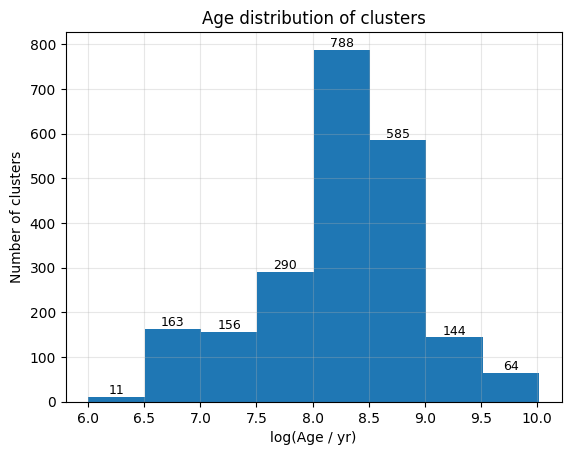

In [79]:
import matplotlib.pyplot as plt
import numpy as np

counts, bin_edges, patches = plt.hist(frac["LogAge_total"], bins=8)

# centro de cada bin
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# adicionar os valores acima das barras
for c, x in zip(counts, bin_centers):
    if c > 0:
        plt.text(x, c, f"{int(c)}", ha="center", va="bottom", fontsize=9)

plt.xlabel("log(Age / yr)")
plt.ylabel("Number of clusters")
plt.title("Age distribution of clusters")
plt.grid(alpha=0.3)

plt.show()

In [80]:
frac['LogAge_total'].describe()

count    2201.000000
mean        8.258855
std         0.678807
min         6.000000
25%         7.970000
50%         8.310000
75%         8.700000
max        10.020000
Name: LogAge_total, dtype: float64

In [81]:
from scipy.stats import beta

alpha = 0.32  # ~68% CI

frac["f_be_low"] = beta.ppf(
    alpha / 2,
    frac["counts_be_stars"] + 1,
    frac["counts_all_stars"] - frac["counts_be_stars"] + 1
)

frac["f_be_high"] = beta.ppf(
    1 - alpha / 2,
    frac["counts_be_stars"] + 1,
    frac["counts_all_stars"] - frac["counts_be_stars"] + 1
)

In [83]:
from scipy.stats import spearmanr

frac2 = frac.dropna(subset=['LogAge_total', 'fraction_be_stars'])

r, p = spearmanr(frac2["LogAge_total"], frac2["fraction_be_stars"])
print(f"Spearman r = {r:.3f}, p = {p:.2e}")

from scipy.stats import kendalltau

tau, p = kendalltau(frac2["LogAge_total"], frac2["fraction_be_stars"])
print(f"Kendall tau = {tau:.3f}, p = {p:.2e}")

Spearman r = -0.263, p = 2.89e-36
Kendall tau = -0.190, p = 4.39e-35


/tmp/ipykernel_3590/3911891059.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = frac.groupby("age_bin")


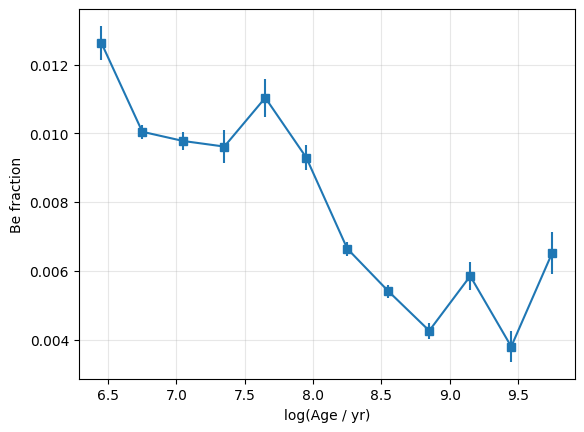

In [96]:
bins = np.arange(6, 10, 0.3)  # ajuste conforme seu range
frac["age_bin"] = pd.cut(frac["LogAge_total"], bins=bins)

grp = frac.groupby("age_bin")

binned = grp.agg(
    n_be=("counts_be_stars", "sum"),
    n_total=("counts_all_stars", "sum")
).reset_index()

binned["fraction_be_stars"] = binned["n_be"] / binned["n_total"]

binned["f_be_err"] = np.sqrt(
    binned["fraction_be_stars"] * (1 - binned["fraction_be_stars"]) / binned["n_total"]
)

bin_centers = bins[:-1] + np.diff(bins)/2

plt.errorbar(
    bin_centers,
    binned["fraction_be_stars"],
    yerr=binned["f_be_err"],
    fmt="s-"
)


plt.xlabel("log(Age / yr)")
plt.ylabel("Be fraction")
plt.grid(alpha=0.3)
plt.show()

In [97]:
binned

,age_bin,n_be,n_total,fraction_be_stars,f_be_err
0,"(6.0, 6.3]",0.0,0,NaN,NaN
1,"(6.3, 6.6]",655.0,51852,0.012632,0.000490
2,"(6.6, 6.9]",2359.0,234874,0.010044,0.000206
3,"(6.9, 7.2]",1400.0,143223,0.009775,0.000260
4,"(7.2, 7.5]",418.0,43482,0.009613,0.000468
5,"(7.5, 7.8]",392.0,35528,0.011034,0.000554
6,"(7.8, 8.1]",687.0,73925,0.009293,0.000353
7,"(8.1, 8.4]",1107.0,166633,0.006643,0.000199
8,"(8.4, 8.7]",842.0,155688,0.005408,0.000186
9,"(8.7, 9.0]",334.0,78471,0.004256,0.000232


In [98]:
from scipy.stats import spearmanr
mask = (
    np.isfinite(bin_centers)
    & np.isfinite(binned["fraction_be_stars"])
    & (binned["n_total"] > 0)
)

x = bin_centers[mask]
y = binned.loc[mask, "fraction_be_stars"]
r_bin, p_bin = spearmanr(
    x,
    y
)

print(r_bin, p_bin)

-0.8671328671328673 0.00025981184986148103


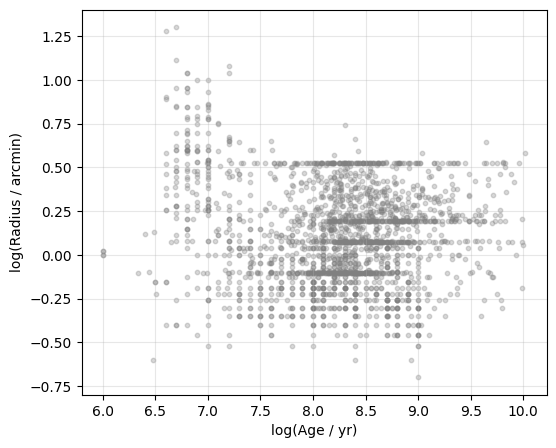

In [89]:
plt.figure(figsize=(6,5))

plt.scatter(
    frac["LogAge_total"],
    np.log10(frac["amaj"]),
    s=10,
    alpha=0.3,
    color="gray"
)

plt.xlabel("log(Age / yr)")
plt.ylabel("log(Radius / arcmin)")
plt.grid(alpha=0.3)
plt.show()

/tmp/ipykernel_3590/670538419.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby("age_bin")


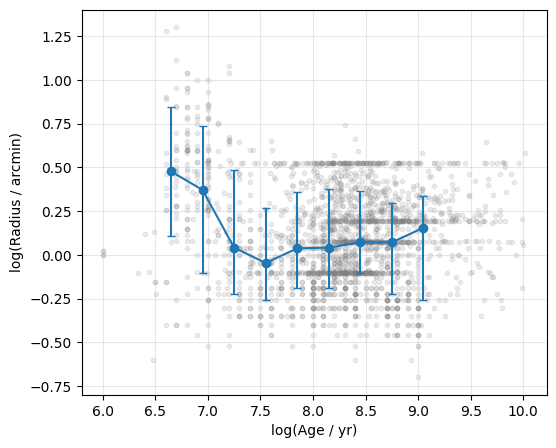

In [90]:
df = frac

bins = np.arange(6.5, 9.5, 0.3)
df["age_bin"] = pd.cut(df["LogAge_total"], bins)

grp = df.groupby("age_bin")

binned = grp["amaj"].agg(
    median="median",
    p16=lambda x: np.percentile(x, 16),
    p84=lambda x: np.percentile(x, 84)
).reset_index()

bin_centers = bins[:-1] + np.diff(bins)/2

plt.figure(figsize=(6,5))

plt.scatter(
    df["LogAge_total"],
    np.log10(df["amaj"]),
    s=10,
    alpha=0.15,
    color="gray"
)

plt.errorbar(
    bin_centers,
    np.log10(binned["median"]),
    yerr=[
        np.log10(binned["median"]) - np.log10(binned["p16"]),
        np.log10(binned["p84"]) - np.log10(binned["median"])
    ],
    fmt="o-",
    color="tab:blue",
    capsize=3
)

plt.xlabel("log(Age / yr)")
plt.ylabel("log(Radius / arcmin)")
plt.grid(alpha=0.3)
plt.show()

<Figure size 1500x1000 with 0 Axes>

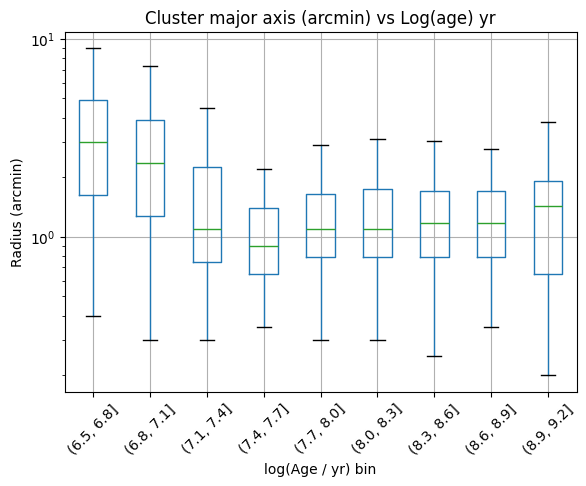

In [91]:
plt.figure(figsize=(15,10))

df.boxplot(
    column="amaj",
    by="age_bin",
    showfliers=False
)

plt.yscale("log")
plt.xlabel("log(Age / yr) bin")
plt.ylabel("Radius (arcmin)")
plt.suptitle("")
plt.title("Cluster major axis (arcmin) vs Log(age) yr")
plt.xticks(rotation=45)
plt.show()

In [99]:
binned

,age_bin,n_be,n_total,fraction_be_stars,f_be_err
0,"(6.0, 6.3]",0.0,0,NaN,NaN
1,"(6.3, 6.6]",655.0,51852,0.012632,0.000490
2,"(6.6, 6.9]",2359.0,234874,0.010044,0.000206
3,"(6.9, 7.2]",1400.0,143223,0.009775,0.000260
4,"(7.2, 7.5]",418.0,43482,0.009613,0.000468
5,"(7.5, 7.8]",392.0,35528,0.011034,0.000554
6,"(7.8, 8.1]",687.0,73925,0.009293,0.000353
7,"(8.1, 8.4]",1107.0,166633,0.006643,0.000199
8,"(8.4, 8.7]",842.0,155688,0.005408,0.000186
9,"(8.7, 9.0]",334.0,78471,0.004256,0.000232


/tmp/ipykernel_3549/4041989134.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby("age_bin")


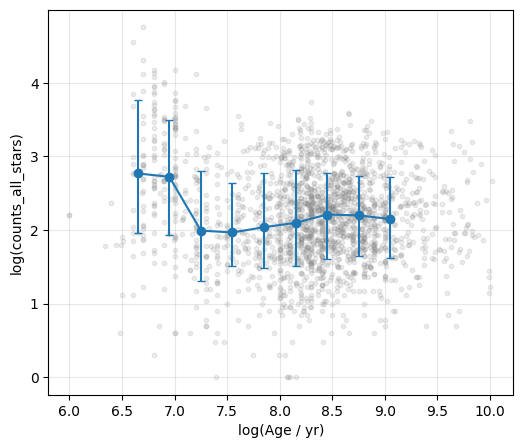

In [21]:
df = frac

bins = np.arange(6.5, 9.5, 0.3)
df["age_bin"] = pd.cut(df["logAge"], bins)

grp = df.groupby("age_bin")

binned = grp["counts_all_stars"].agg(
    median="median",
    p16=lambda x: np.percentile(x, 16),
    p84=lambda x: np.percentile(x, 84)
).reset_index()

bin_centers = bins[:-1] + np.diff(bins)/2

plt.figure(figsize=(6,5))

plt.scatter(
    df["logAge"],
    np.log10(df["counts_all_stars"]),
    s=10,
    alpha=0.15,
    color="gray"
)

plt.errorbar(
    bin_centers,
    np.log10(binned["median"]),
    yerr=[
        np.log10(binned["median"]) - np.log10(binned["p16"]),
        np.log10(binned["p84"]) - np.log10(binned["median"])
    ],
    fmt="o-",
    color="tab:blue",
    capsize=3
)

plt.xlabel("log(Age / yr)")
plt.ylabel("log(counts_all_stars)")
plt.grid(alpha=0.3)
plt.show()

/tmp/ipykernel_3590/3792708550.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  frac3["age_bin"] = pd.cut(frac3["LogAge_total"], bins=bins)
/tmp/ipykernel_3590/3792708550.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = frac3.groupby("age_bin")


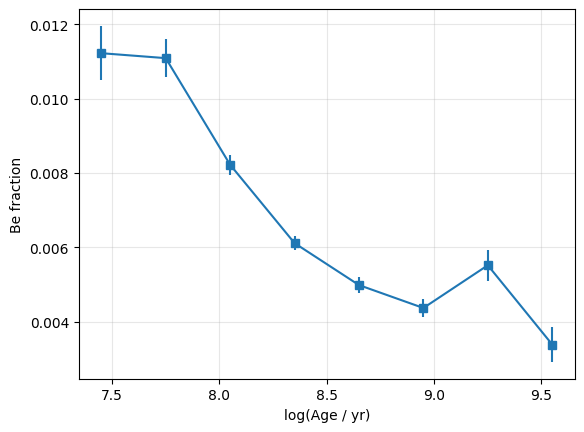

-0.9285714285714287 0.0008629681828999769


In [94]:
frac3 = frac[frac['LogAge_total'].between(7.4, 10.0)]

bins = np.arange(7, 10, 0.3)  # ajuste conforme seu range
frac3["age_bin"] = pd.cut(frac3["LogAge_total"], bins=bins)

grp = frac3.groupby("age_bin")

binned = grp.agg(
    n_be=("counts_be_stars", "sum"),
    n_total=("counts_all_stars", "sum")
).reset_index()

binned["fraction_be_stars"] = binned["n_be"] / binned["n_total"]

binned["f_be_err"] = np.sqrt(
    binned["fraction_be_stars"] * (1 - binned["fraction_be_stars"]) / binned["n_total"]
)

bin_centers = bins[:-1] + np.diff(bins)/2

plt.errorbar(
    bin_centers,
    binned["fraction_be_stars"],
    yerr=binned["f_be_err"],
    fmt="s-"
)


plt.xlabel("log(Age / yr)")
plt.ylabel("Be fraction")
plt.grid(alpha=0.3)
plt.show()


from scipy.stats import spearmanr
mask = (
    np.isfinite(bin_centers)
    & np.isfinite(binned["fraction_be_stars"])
    & (binned["n_total"] > 0)
)

x = bin_centers[mask]
y = binned.loc[mask, "fraction_be_stars"]
r_bin, p_bin = spearmanr(
    x,
    y
)

print(r_bin, p_bin)

In [101]:
import pandas as pd
import numpy as np

x = frac["LogAge_total"]

# Ex.: 10 bins = decíis (0–10%, 10–20%, ...)
frac["age_pct_bin"] = pd.qcut(x, q=20, labels=False, duplicates="drop")  # 0..9

In [104]:
binned = (
    frac.groupby("age_pct_bin")
    .agg(
        n_be=("counts_be_stars", "sum"),
        n_total=("counts_all_stars", "sum"),
        median_logAge=("LogAge_total", "median"),
        min_logAge=("LogAge_total", "min"),
        max_logAge=("LogAge_total", "max"),
        num_clusters=("cluster_Names", "nunique"),
    )
    .reset_index()
)

binned["f_be"] = binned["n_be"] / binned["n_total"]
binned["f_be_err"] = np.sqrt(
    binned["f_be"] * (1 - binned["f_be"]) / binned["n_total"]
)

In [105]:
binned

,age_pct_bin,n_be,n_total,median_logAge,min_logAge,max_logAge,num_clusters,f_be,f_be_err
0,0.0,3515.0,331674,6.80,6.00,6.90,119,0.010598,0.000178
1,1.0,1101.0,120454,7.08,6.95,7.20,109,0.009140,0.000274
2,2.0,284.0,25349,7.40,7.22,7.53,101,0.011204,0.000661
3,3.0,371.0,34051,7.70,7.54,7.80,123,0.010895,0.000563
4,4.0,325.0,31928,7.90,7.80,7.97,99,0.010179,0.000562
5,5.0,245.0,27966,8.00,7.98,8.05,107,0.008761,0.000557
6,6.0,203.0,30287,8.10,8.06,8.14,117,0.006703,0.000469
7,7.0,340.0,42532,8.20,8.15,8.20,123,0.007994,0.000432
8,8.0,184.0,33031,8.25,8.21,8.27,93,0.005571,0.000410
9,9.0,262.0,36161,8.30,8.28,8.31,109,0.007245,0.000446


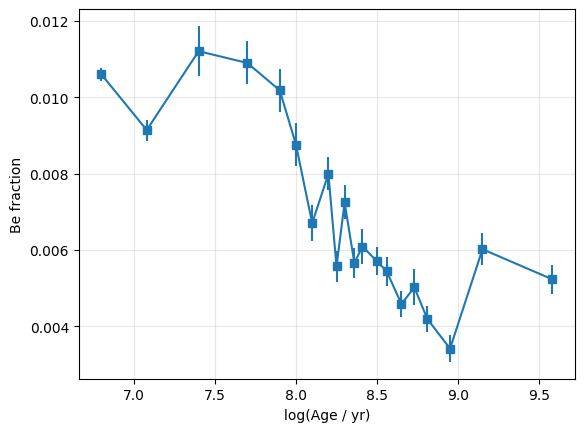

In [106]:
plt.errorbar(
    binned["median_logAge"],
    binned["f_be"],
    yerr=binned["f_be_err"],
    fmt="s-"
)

plt.xlabel("log(Age / yr)")
plt.ylabel("Be fraction")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from scipy.stats import spearmanr

r, p = spearmanr(
    binned["median_logAge"],
    binned["f_be"]
)

print(r, p)

-0.9248120300751879 5.539165176617526e-09


In [121]:
bica

,Names,amaj,bmin,l_logAge,logAge,r_logAge,[M/H],r_[M/H],SimbadName,ra_deg,dec_deg,host,region,a_host_deg,phi_host_deg,sep_host_deg
0,L2,1.20,1.20,NaN,NaN,NaN,NaN,NaN,ClLindsay2,3.229170,-73.487500,SMC,SMC: Counter-Bridge,3.782166,152.563464,2.956048
1,"L3,ESO28SC13",1.00,1.00,NaN,NaN,NaN,NaN,NaN,ClLindsay3,4.604170,-74.318610,SMC,SMC: Counter-Bridge,2.956597,170.569541,2.844014
2,BS1,0.90,0.90,NaN,NaN,NaN,NaN,NaN,[BS95]1,4.737500,-73.414440,SMC,SMC: Counter-Bridge,3.231062,152.411427,2.520328
3,BS127,1.00,1.00,NaN,NaN,NaN,NaN,NaN,[BS95]127,16.250000,-71.142780,SMC,SMC: Wing/Bridge,2.102299,14.243756,1.933926
4,BS198,1.00,0.75,NaN,NaN,NaN,NaN,NaN,[BS95]198,27.000000,-73.132780,SMC,SMC: Wing/Bridge,7.068967,-55.859573,4.044193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5842,BBica 19,0.75,0.75,,,,,,NaN,58.424167,-73.934167,LMC,LMC: Northern Arm,11.327972,106.091779,8.083041
5843,ICA74,4.20,2.10,,,,,,ICA74,58.458333,-73.921667,LMC,LMC: Northern Arm,11.311204,106.031494,8.069903
5844,ICA75,2.00,1.40,,,,,,ICA75,60.512500,-74.069444,LMC,LMC: Northern Arm,10.579923,108.607557,7.600472
5845,"IDK6,ICA76",7.00,6.00,<,7.00,"DGI+91,GDK92",,,IDK6,64.870833,-73.896944,LMC,LMC: Northern Arm,8.893757,112.024473,6.458244


In [145]:
len(frac[frac['counts_be_stars'] == 0])

3670

In [ ]:
frac[frac['fraction_be_stars']]

,cluster_Names,counts_be_stars,counts_all_stars,fraction_be_stars,[M/H],amaj,Cross-ID,Vmag,e_Vmag,LogAge_total,ra_deg,dec_deg,f_be_low,f_be_high,age_bin,age_pct_bin
0,B-OB1,3.0,360,0.008333,,3.70,NaN,NaN,NaN,8.2,11.391667,-73.257222,0.005805,0.016288,"(8.1, 8.4]",7.0
1,B-OB11,1.0,376,0.002660,,3.00,NaN,NaN,NaN,NaN,13.537500,-72.710833,0.001889,0.008696,NaN,NaN
2,B-OB12,15.0,3543,0.004234,,4.50,NaN,NaN,NaN,7.6,13.841667,-72.782500,0.003405,0.005621,"(7.5, 7.8]",3.0
3,B-OB13,54.0,7138,0.007565,,9.00,NaN,NaN,NaN,6.8,14.491667,-72.548333,0.006677,0.008728,"(6.6, 6.9]",0.0
4,B-OB14,33.0,9597,0.003439,,7.00,NaN,NaN,NaN,6.9,14.908333,-72.747222,0.002942,0.004142,"(6.9, 7.2]",0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5563,"ZHT-SP2,LOGLE37",0.0,114,0.000000,NaN,0.95,NaN,NaN,NaN,NaN,75.833330,-66.981110,0.001515,0.015809,NaN,NaN
5564,ZHT12,0.0,60,0.000000,NaN,0.65,NaN,NaN,NaN,NaN,79.175000,-67.803060,0.002854,0.029596,NaN,NaN
5565,ZHT2,0.0,112,0.000000,NaN,0.60,NaN,NaN,NaN,NaN,75.620830,-66.610830,0.001542,0.016087,NaN,NaN
5566,"ZHT3,LOGLE88",0.0,135,0.000000,NaN,1.50,NaN,NaN,NaN,NaN,76.475000,-66.733330,0.001281,0.013384,NaN,NaN


In [112]:
import numpy as np
import pandas as pd

# Série original
x_all = frac["fraction_be_stars"].dropna()

# Série sem zeros
x_nozero = x_all[x_all > 0]

def quartis(x):
    return pd.Series(
        np.percentile(x, [25, 50, 75]),
        index=["Q1", "Mediana", "Q3"]
    )

q_all = quartis(x_all)
q_nozero = quartis(x_nozero)

quartis_df = pd.DataFrame({
    "Com zeros": q_all,
    "Sem zeros": q_nozero
})

print(quartis_df)

         Com zeros  Sem zeros
Q1        0.000000   0.005800
Mediana   0.000000   0.010753
Q3        0.006099   0.018868


In [113]:
from scipy.stats import ks_2samp

ks_stat, ks_pval = ks_2samp(x_all, x_nozero)

print(f"KS statistic = {ks_stat:.3f}")
print(f"p-value = {ks_pval:.3e}")

KS statistic = 0.659
p-value = 2.159e-321


In [116]:
import numpy as np

x = frac["fraction_be_stars"].dropna()

Q1, Q3 = np.percentile(x, [25, 75])
IQR = Q3 - Q1

k = 1.5  # padrão
mask = (x >= Q1 - k*IQR) & (x <= Q3 + k*IQR)

x_iqr = x[mask]

print(f"Removidos: {len(x) - len(x_iqr)} pontos")

Removidos: 633 pontos


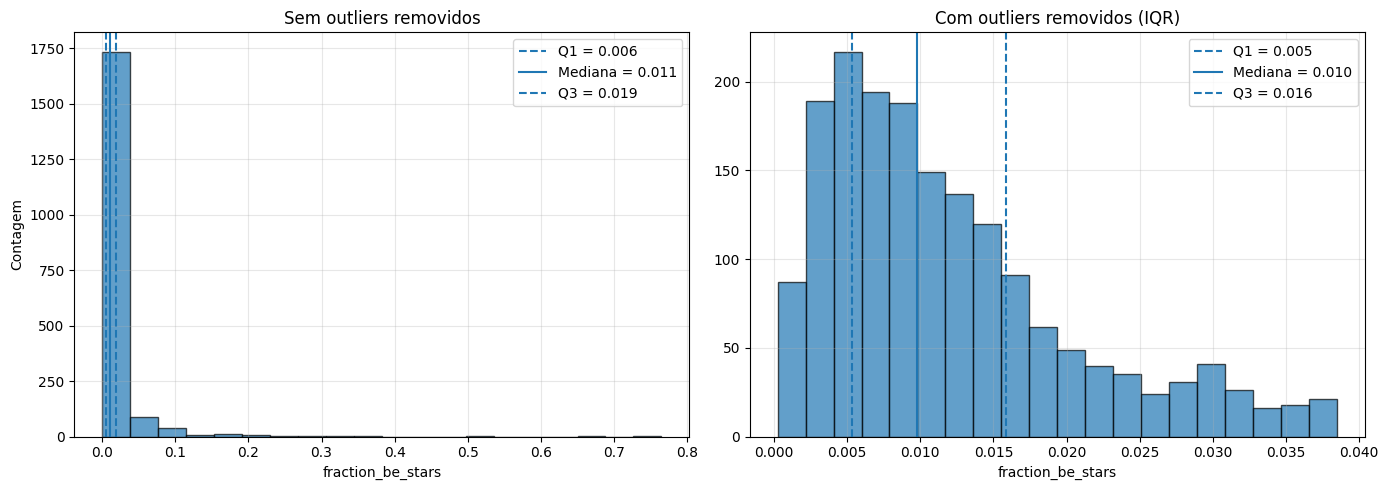

In [126]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# Dados base (sem zeros)
# ===============================
x = frac.loc[frac["fraction_be_stars"] != 0, "fraction_be_stars"].dropna()

# Quartis originais
q1, q2, q3 = np.percentile(x, [25, 50, 75])

# ===============================
# Remoção de outliers (IQR)
# ===============================
IQR = q3 - q1
mask = (x >= q1 - 1.5 * IQR) & (x <= q3 + 1.5 * IQR)
x_iqr = x[mask]

# Quartis após remoção
q1_i, q2_i, q3_i = np.percentile(x_iqr, [25, 50, 75])

# ===============================
# Plot lado a lado
# ===============================
plt.figure(figsize=(14, 5))

# --------- Plot 1: original ---------
plt.subplot(1, 2, 1)
plt.hist(x, bins=20, alpha=0.7, edgecolor="black")

plt.axvline(q1, linestyle="--", label=f"Q1 = {q1:.3f}")
plt.axvline(q2, linestyle="-",  label=f"Mediana = {q2:.3f}")
plt.axvline(q3, linestyle="--", label=f"Q3 = {q3:.3f}")

plt.xlabel("fraction_be_stars")
plt.ylabel("Contagem")
plt.title("Sem outliers removidos")
plt.legend()
plt.grid(alpha=0.3)

# --------- Plot 2: sem outliers ---------
plt.subplot(1, 2, 2)
plt.hist(x_iqr, bins=20, alpha=0.7, edgecolor="black")

plt.axvline(q1_i, linestyle="--", label=f"Q1 = {q1_i:.3f}")
plt.axvline(q2_i, linestyle="-",  label=f"Mediana = {q2_i:.3f}")
plt.axvline(q3_i, linestyle="--", label=f"Q3 = {q3_i:.3f}")

plt.xlabel("fraction_be_stars")
plt.title("Com outliers removidos (IQR)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

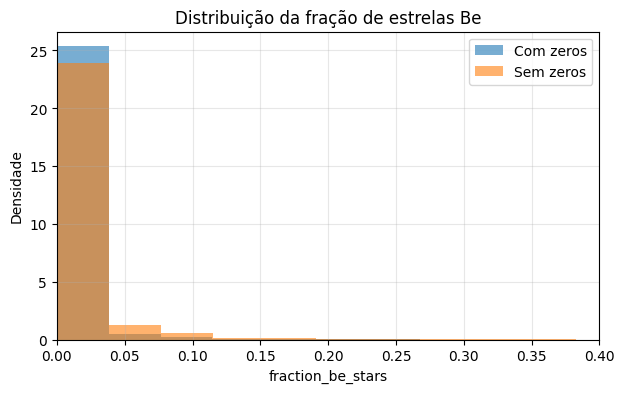

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.hist(x_all, bins=20, density=True, alpha=0.6, label="Com zeros")
plt.hist(x_nozero, bins=20, density=True, alpha=0.6, label="Sem zeros")
plt.xlim(0, 0.4)
plt.xlabel("fraction_be_stars")
plt.ylabel("Densidade")
plt.title("Distribuição da fração de estrelas Be")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

/tmp/ipykernel_3590/202492842.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


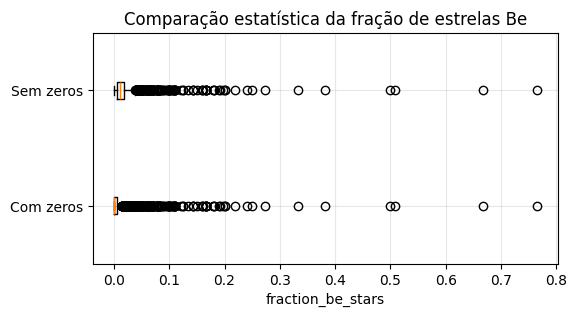

In [115]:
plt.figure(figsize=(6, 3))
plt.boxplot(
    [x_all, x_nozero],
    labels=["Com zeros", "Sem zeros"],
    vert=False
)

plt.xlabel("fraction_be_stars")
plt.title("Comparação estatística da fração de estrelas Be")
plt.grid(alpha=0.3)

plt.show()

In [124]:
from astroquery.vizier import Vizier

Vizier.ROW_LIMIT = -1
# o catálogo J/A+A/517/A50 tem tabelas; a principal costuma ser "table1" (pode variar)
# A melhor prática é inspecionar as tabelas retornadas.
bica08 = Vizier.get_catalogs("J/MNRAS/389/678")

# escolha a "maior" tabela (geralmente a principal com os objetos)
tables = list(bica08)
tbl = max(tables, key=lambda t: len(t))

df1 = tbl.to_pandas()


Vizier.ROW_LIMIT = -1
# o catálogo J/A+A/517/A50 tem tabelas; a principal costuma ser "table1" (pode variar)
# A melhor prática é inspecionar as tabelas retornadas.
bica20 = Vizier.get_catalogs("J/AJ/159/82")

# escolha a "maior" tabela (geralmente a principal com os objetos)
tables = list(bica20)
tbl = max(tables, key=lambda t: len(t))

df2 = tbl.to_pandas()

In [146]:
df1

,Names,RAJ2000,DEJ2000,Type,amaj,amin,PA,Com,SimbadName
0,"AM-3,ESO28SC4",23 48 59,-72 56 43,C,0.90,0.90,<NA>,Old IAC,ESO 28-4
1,"L1,ESO28SC8",00 03 54,-73 28 19,C,4.60,4.60,<NA>,Globular Cluster,ESO 28-8
2,L2,00 12 55,-73 29 15,C,1.20,1.20,<NA>,,Cl Lindsay 2
3,"L3,ESO28SC13",00 18 25,-74 19 07,C,1.00,1.00,<NA>,,Cl Lindsay 3
4,HW1,00 18 27,-73 23 42,CA,0.95,0.85,<NA>,,HW 1
...,...,...,...,...,...,...,...,...,...
3735,"SL896,LW480,KMHK1758",06 29 58,-69 20 01,C,1.00,1.00,<NA>,,[SL63] 896
3736,"NGC2257,SL895,LW481,ESO87SC24,",06 30 12,-64 19 34,C,4.00,4.00,<NA>,& KMHK1756 Globular Cluster,NGC 2257
3737,"LW482,KMHK1759",06 32 21,-72 28 23,C,0.80,0.80,<NA>,,LW482
3738,"SL897,LW483,KMHK1760",06 33 01,-71 07 40,C,1.50,1.50,<NA>,,[SL63] 897


In [137]:
df3 = df1.merge(
    df2,
    left_on="Names",
    right_on="Names",
    how="outer",
    suffixes=("_2008", "_2020")
)

In [141]:
df3['Names'].unique().shape[0]

6151

In [144]:
bica

,Names,amaj,bmin,l_logAge,logAge,r_logAge,[M/H],r_[M/H],SimbadName,ra_deg,dec_deg,host,region,a_host_deg,phi_host_deg,sep_host_deg
0,L2,1.20,1.20,NaN,NaN,NaN,NaN,NaN,ClLindsay2,3.229170,-73.487500,SMC,SMC: Counter-Bridge,3.782166,152.563464,2.956048
1,"L3,ESO28SC13",1.00,1.00,NaN,NaN,NaN,NaN,NaN,ClLindsay3,4.604170,-74.318610,SMC,SMC: Counter-Bridge,2.956597,170.569541,2.844014
2,BS1,0.90,0.90,NaN,NaN,NaN,NaN,NaN,[BS95]1,4.737500,-73.414440,SMC,SMC: Counter-Bridge,3.231062,152.411427,2.520328
3,BS127,1.00,1.00,NaN,NaN,NaN,NaN,NaN,[BS95]127,16.250000,-71.142780,SMC,SMC: Wing/Bridge,2.102299,14.243756,1.933926
4,BS198,1.00,0.75,NaN,NaN,NaN,NaN,NaN,[BS95]198,27.000000,-73.132780,SMC,SMC: Wing/Bridge,7.068967,-55.859573,4.044193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5842,BBica 19,0.75,0.75,,,,,,NaN,58.424167,-73.934167,LMC,LMC: Northern Arm,11.327972,106.091779,8.083041
5843,ICA74,4.20,2.10,,,,,,ICA74,58.458333,-73.921667,LMC,LMC: Northern Arm,11.311204,106.031494,8.069903
5844,ICA75,2.00,1.40,,,,,,ICA75,60.512500,-74.069444,LMC,LMC: Northern Arm,10.579923,108.607557,7.600472
5845,"IDK6,ICA76",7.00,6.00,<,7.00,"DGI+91,GDK92",,,IDK6,64.870833,-73.896944,LMC,LMC: Northern Arm,8.893757,112.024473,6.458244


In [147]:
frac

,cluster_Names,counts_be_stars,counts_all_stars,fraction_be_stars,[M/H],amaj,Cross-ID,Vmag,e_Vmag,LogAge_total,ra_deg,dec_deg,f_be_low,f_be_high,age_bin,age_pct_bin,Names,SimbadName
0,B-OB1,3.0,360,0.008333,,3.70,NaN,NaN,NaN,8.2,11.391667,-73.257222,0.005805,0.016288,"(8.1, 8.4]",7.0,B-OB1,[B91] 1
1,B-OB11,1.0,376,0.002660,,3.00,NaN,NaN,NaN,NaN,13.537500,-72.710833,0.001889,0.008696,NaN,NaN,B-OB11,[B91] 11
2,B-OB12,15.0,3543,0.004234,,4.50,NaN,NaN,NaN,7.6,13.841667,-72.782500,0.003405,0.005621,"(7.5, 7.8]",3.0,B-OB12,[B91] 12
3,B-OB13,54.0,7138,0.007565,,9.00,NaN,NaN,NaN,6.8,14.491667,-72.548333,0.006677,0.008728,"(6.6, 6.9]",0.0,B-OB13,[B91] 13
4,B-OB14,33.0,9597,0.003439,,7.00,NaN,NaN,NaN,6.9,14.908333,-72.747222,0.002942,0.004142,"(6.9, 7.2]",0.0,B-OB14,[B91] 14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5571,"ZHT-SP2,LOGLE37",0.0,114,0.000000,NaN,0.95,NaN,NaN,NaN,NaN,75.833330,-66.981110,0.001515,0.015809,NaN,NaN,"ZHT-SP2,LOGLE37",OGLE-CL LMC 37
5572,ZHT12,0.0,60,0.000000,NaN,0.65,NaN,NaN,NaN,NaN,79.175000,-67.803060,0.002854,0.029596,NaN,NaN,ZHT12,ZHT AN 12
5573,ZHT2,0.0,112,0.000000,NaN,0.60,NaN,NaN,NaN,NaN,75.620830,-66.610830,0.001542,0.016087,NaN,NaN,ZHT2,ZHT AN 2
5574,"ZHT3,LOGLE88",0.0,135,0.000000,NaN,1.50,NaN,NaN,NaN,NaN,76.475000,-66.733330,0.001281,0.013384,NaN,NaN,"ZHT3,LOGLE88",ZHT AN 3


In [142]:
df3

,Names,RAJ2000_2008,DEJ2000_2008,Type_2008,amaj_2008,amin,PA,Com,SimbadName_2008,RAJ2000_2020,...,amaj_2020,bmin,l_logAge,logAge,r_logAge,[M/H],r_[M/H],PapI,B18,SimbadName_2020
0,"2,OGLS 312,OGLS 328",NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,00 12 56.9,...,1.2,1.2,,9.60,DKB+14,-1.58,DKB+16,0.0,B18,OGLE-CL SMC 328;OGLE-CL SMC 312
1,"AM 3,ESO28SC4,OGLS 315",NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,23 48 59.3,...,0.9,0.9,,9.72,"PGC+14,DKB+14",-0.98,DKB+16,1.0,B18,OGLE-CL SMC 315
2,"AM-3,ESO28SC4",23 48 59,-72 56 43,C,0.90,0.90,<NA>,Old IAC,ESO 28-4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,B-OB1,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,00 45 34.0,...,3.7,3.0,,8.20,CVH+06,NaN,,1.0,B18,[B91] 1
4,B-OB11,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,00 54 09.0,...,3.0,3.0,,NaN,,NaN,,1.0,B18,[B91] 11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6148,ZHT-SP5,05 13 32,-67 10 28,CN,0.60,0.55,10,in DEML107,,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6149,ZHT12,05 16 42,-67 48 11,C,0.65,0.60,160,,ZHT AN 12,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6150,ZHT2,05 02 29,-66 36 39,CA,0.60,0.45,70,in DEML56,ZHT AN 2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6151,"ZHT3,LOGLE88",05 05 54,-66 44 00,C,1.50,1.10,10,,ZHT AN 3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [143]:
df3.to_csv("FullCatalogBica_08_20_Vizier.csv", index=False)

In [123]:
df1

,Names,RAJ2000,DEJ2000,Type,amaj,amin,PA,Com,SimbadName
0,"AM-3,ESO28SC4",23 48 59,-72 56 43,C,0.90,0.90,<NA>,Old IAC,ESO 28-4
1,"L1,ESO28SC8",00 03 54,-73 28 19,C,4.60,4.60,<NA>,Globular Cluster,ESO 28-8
2,L2,00 12 55,-73 29 15,C,1.20,1.20,<NA>,,Cl Lindsay 2
3,"L3,ESO28SC13",00 18 25,-74 19 07,C,1.00,1.00,<NA>,,Cl Lindsay 3
4,HW1,00 18 27,-73 23 42,CA,0.95,0.85,<NA>,,HW 1
...,...,...,...,...,...,...,...,...,...
3735,"SL896,LW480,KMHK1758",06 29 58,-69 20 01,C,1.00,1.00,<NA>,,[SL63] 896
3736,"NGC2257,SL895,LW481,ESO87SC24,",06 30 12,-64 19 34,C,4.00,4.00,<NA>,& KMHK1756 Globular Cluster,NGC 2257
3737,"LW482,KMHK1759",06 32 21,-72 28 23,C,0.80,0.80,<NA>,,LW482
3738,"SL897,LW483,KMHK1760",06 33 01,-71 07 40,C,1.50,1.50,<NA>,,[SL63] 897


In [135]:
frac = frac.merge(bica[['Names','SimbadName']], left_on='cluster_Names', right_on='Names', how='left')

In [136]:
frac

,cluster_Names,counts_be_stars,counts_all_stars,fraction_be_stars,[M/H],amaj,Cross-ID,Vmag,e_Vmag,LogAge_total,ra_deg,dec_deg,f_be_low,f_be_high,age_bin,age_pct_bin,Names,SimbadName
0,B-OB1,3.0,360,0.008333,,3.70,NaN,NaN,NaN,8.2,11.391667,-73.257222,0.005805,0.016288,"(8.1, 8.4]",7.0,B-OB1,[B91] 1
1,B-OB11,1.0,376,0.002660,,3.00,NaN,NaN,NaN,NaN,13.537500,-72.710833,0.001889,0.008696,NaN,NaN,B-OB11,[B91] 11
2,B-OB12,15.0,3543,0.004234,,4.50,NaN,NaN,NaN,7.6,13.841667,-72.782500,0.003405,0.005621,"(7.5, 7.8]",3.0,B-OB12,[B91] 12
3,B-OB13,54.0,7138,0.007565,,9.00,NaN,NaN,NaN,6.8,14.491667,-72.548333,0.006677,0.008728,"(6.6, 6.9]",0.0,B-OB13,[B91] 13
4,B-OB14,33.0,9597,0.003439,,7.00,NaN,NaN,NaN,6.9,14.908333,-72.747222,0.002942,0.004142,"(6.9, 7.2]",0.0,B-OB14,[B91] 14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5571,"ZHT-SP2,LOGLE37",0.0,114,0.000000,NaN,0.95,NaN,NaN,NaN,NaN,75.833330,-66.981110,0.001515,0.015809,NaN,NaN,"ZHT-SP2,LOGLE37",OGLE-CL LMC 37
5572,ZHT12,0.0,60,0.000000,NaN,0.65,NaN,NaN,NaN,NaN,79.175000,-67.803060,0.002854,0.029596,NaN,NaN,ZHT12,ZHT AN 12
5573,ZHT2,0.0,112,0.000000,NaN,0.60,NaN,NaN,NaN,NaN,75.620830,-66.610830,0.001542,0.016087,NaN,NaN,ZHT2,ZHT AN 2
5574,"ZHT3,LOGLE88",0.0,135,0.000000,NaN,1.50,NaN,NaN,NaN,NaN,76.475000,-66.733330,0.001281,0.013384,NaN,NaN,"ZHT3,LOGLE88",ZHT AN 3


# adding new ages from Glatt et al. 2010

In [52]:
import re
import pandas as pd
from astroquery.vizier import Vizier

cluster_names = frac[(frac['LogAge_total'].isna()) 
    #  & (frac['fraction_be_stars'] < 0.005813953488372)
    #  & (frac['fraction_be_stars'] != 0)
     ].cluster_Names.tolist()
# ---- helpers ----
def norm_name(s: str) -> str:
    """Normaliza para bater nomes tipo 'BSDL1018' vs 'BSDL 1018'."""
    s = (s or "").strip()
    s = re.sub(r"\s+", " ", s)
    s = s.upper()
    # remove espaços e pontuação comum para criar chave "agressiva"
    key = re.sub(r"[^A-Z0-9]+", "", s)
    return key

def first_token_before_comma(s: str) -> str:
    s = (s or "").strip()
    return s.split(",", 1)[0].strip()

# ---- 2) baixa o catálogo do VizieR (Glatt+2010) ----
Vizier.ROW_LIMIT = -1
# o catálogo J/A+A/517/A50 tem tabelas; a principal costuma ser "table1" (pode variar)
# A melhor prática é inspecionar as tabelas retornadas.
res = Vizier.get_catalogs("J/A+A/517/A50")

# escolha a "maior" tabela (geralmente a principal com os objetos)
tables = list(res)
tbl = max(tables, key=lambda t: len(t))

df = tbl.to_pandas()


In [53]:
df

,Name,n_Name,E(B-V),R,l_Age,Age,q_Age,Age2,RAJ2000,DEJ2000,Vmag,e_Vmag,SimbadName,Cross-ID
0,LMC0020,,0.02,0.750,,8.80,1,NaN,04 37 51,-69 01 45,13.890000,0.14,[SL63] 8,"SL8,LW13,KMHK21"
1,LMC0021,,0.08,0.290,,8.00,1,NaN,04 38 07,-68 46 39,14.290000,0.14,KMHK22,"NGC1649,ESO55SC31,KMHK22"
2,LMC0022,,0.08,0.750,,8.50,1,NaN,04 38 22,-68 40 21,13.110000,0.14,NGC1652,"NGC1652,SL10,LW14, ESO55SC32,KMHK23"
3,LMC0030,,0.02,0.550,,8.30,2,NaN,04 40 28,-69 38 57,13.730000,0.12,[SL63] 14,"SL14,LW21,KMHK28"
4,LMC0031,,0.02,0.650,,8.70,1,NaN,04 40 43,-68 21 21,14.210000,0.12,[SL63] 15,"SL15,LW23,KMHK29"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1511,SMC0739,,0.07,0.175,,8.85,1,NaN,00 45 23,-72 55 43,16.209999,0.11,OGLE-CL SMC180,SOGLE180
1512,SMC0740,,0.08,0.300,,8.65,1,NaN,00 45 28,-72 53 09,14.310000,0.11,OGLE-CL SMC181,SOGLE181
1513,SMC0754,,0.10,0.250,,7.80,2,NaN,00 53 17,-72 44 03,13.210000,0.11,[BS95] 256,"BS256,SOGLE215"
1514,SMC0761,,0.05,0.425,,7.70,1,NaN,01 02 53,-72 24 53,13.300000,0.10,Bruck 114,"B114,SOGLE234"


In [ ]:
frac = pd.merge(
    frac,
   df[["Cross-ID", "Age", "Vmag", "e_Vmag"]],
    left_on="cluster_Names",
    right_on="Cross-ID",
    how="left"
)

 # bica[['Names','ra_deg','dec_deg']]

In [60]:
len(frac['LogAge_total'] == '')

5568

In [39]:
frac['LogAge_total'] = frac['logAge'].combine_first(frac['Age'])

In [47]:
frac

,cluster_Names,counts_be_stars,counts_all_stars,fraction_be_stars,[M/H],amaj,Cross-ID,Vmag,e_Vmag,LogAge_total,ra_deg,dec_deg
0,B-OB1,3.0,360,0.008333,,3.70,NaN,NaN,NaN,8.20,11.391667,-73.257222
1,B-OB11,1.0,376,0.002660,,3.00,NaN,NaN,NaN,,13.537500,-72.710833
2,B-OB12,15.0,3543,0.004234,,4.50,NaN,NaN,NaN,7.60,13.841667,-72.782500
3,B-OB13,54.0,7138,0.007565,,9.00,NaN,NaN,NaN,6.80,14.491667,-72.548333
4,B-OB14,33.0,9597,0.003439,,7.00,NaN,NaN,NaN,6.90,14.908333,-72.747222
...,...,...,...,...,...,...,...,...,...,...,...,...
5563,"ZHT-SP2,LOGLE37",0.0,114,0.000000,NaN,0.95,NaN,NaN,NaN,NaN,75.833330,-66.981110
5564,ZHT12,0.0,60,0.000000,NaN,0.65,NaN,NaN,NaN,NaN,79.175000,-67.803060
5565,ZHT2,0.0,112,0.000000,NaN,0.60,NaN,NaN,NaN,NaN,75.620830,-66.610830
5566,"ZHT3,LOGLE88",0.0,135,0.000000,NaN,1.50,NaN,NaN,NaN,NaN,76.475000,-66.733330


In [46]:
frac.to_csv('be_stars_fraction_per_cluster.csv', index=False)